# ⚙️ Chapter 7: Direct Preference Optimization

![Part](https://img.shields.io/badge/Part%20II-Core%20Methods-1F9D6B?style=for-the-badge) &nbsp; ![Tested](https://img.shields.io/badge/Tested-Colab%20T4-2FAE7E?style=for-the-badge) &nbsp; [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arunpshankar/packt-final/blob/main/code/notebooks/part2_core/07_dpo.ipynb)

> 📘 **Book:** *Reinforcement Learning for Large Language Models*, Arun Shankar & Michael Chertushkin (Packt, 2026)  
> 📓 **Notebook:** `part2_core/07_dpo.ipynb`  
> ✅ **Tested on:** Google Colab (T4), 2026-06-29

> 📌 **What this notebook covers**  
> This is the companion notebook for Chapter 7 of the book. Run it on a free Colab T4 GPU. All code uses small, publicly available models (under 500 MB) that fit within the free-tier memory limit.

---

In [1]:
# === Setup: Chapter 7 · tested on Google Colab (T4), 2026-06-29 ===
# Self-contained: installs ONLY what this notebook imports (pinned).
# Versions are managed centrally in code/requirements.txt.
import os, sys
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")  # quiet HF download bars (keeps GitHub able to render the saved notebook)
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q --progress-bar off datasets==4.3.0 transformers==5.5.0 bitsandbytes==0.49.2

import importlib
for _p in ["datasets", "torch", "transformers", "bitsandbytes"]:
    try:
        print(f"{_p:<16}", importlib.import_module(_p).__version__)
    except Exception as _e:
        print(f"{_p:<16} (not importable here)")


datasets         4.3.0
torch            2.11.0+cu128
transformers     5.5.0
bitsandbytes     0.49.2


### Before we start

In the previous chapters we covered the LLM training phases, pretraining, then **Supervised Fine-Tuning (SFT)** on `(prompt, answer)` pairs, and in Chapter 6 we aligned a model with **PPO** (a reward model plus an RL loop).

In this notebook we align a model with **Direct Preference Optimization (DPO)** instead: it learns directly from **preference pairs**, with **no reward model and no RL loop**. Our concrete goal is **tone alignment**, turning verbose, hedging answers into concise, warmer, less-hedging ones.

### What is DPO

**Direct Preference Optimization** (**DPO**) was first suggested for the Human Alignment task as an alternative to the quite finicky Reinforcement Learning procedure based on PPO (Proximal Policy Optimization) algorithm.

Though DPO was invented by analytically finding the maximum of the RLHF loss, it has nothing to do with RL. It's just Supervised Finetuning on a dataset of triplets `(prompt, accepted_completion, rejected_completion)` with a special loss function that stimulates the LLM to prioritize accepted completions and pessimize unwanted ones.

For a while, DPO was quite popular as an algorithm for establishing Human Alignment. But at the time of writing, RL tactics **PPO** (the algorithm behind the original **RLHF**) and **GRPO** (use to train **DeepSeek-R1** for long reasoning) are still considered the mainstream types of post-training. This is especially true outside Human Alignment, in the tasks where completions are scored according to the "correctness" of sorts - might be answer correction or web scenario goal achievement.

Learn more about DPO in the relevant chapters of the Book.


### How is DPO different from SFT?

Previously (in 2023 and 2024), DPO and SFT were in different phases. SFT was on the phase of post-training and DPO was usually applied after SFT during phase of Human Alignment. Today the line between post-training and human alignment became more blurry and DPO and SFT can be applied even in parallel. Let's understand some functional differences between the two:

- While Supervised Fine-Tuning (SFT) teaches a model what to say, Direct Preference Optimization (DPO) teaches it what to prefer.
- SFT treats all demonstrations as ground truth, while DPO contrasts preferred and less preferred outputs to learn a more nuanced decision boundary.
- Unlike SFT, which optimizes the likelihood of single responses, DPO uses relative preference data to optimize over pairs, training the model to assign higher probability to preferred outputs
- DPO achieves similar goals to PPO-based RLHF, but in a fully supervised and differentiable way, avoiding reward models and policy rollouts.


### Ok, but how do we implement DPO?

DPO can be run with HuggingFace's `DPOTrainer`, but here we **implement the loss ourselves**, it's only a few lines, every step is transparent, and it runs on a clean Colab without extra libraries. (A reference cell near the end shows the equivalent `DPOTrainer` usage.)

Our task is **tone alignment**, the kind of thing DPO is famous for: teach the model to answer **more concisely and with a warmer, less-hedging tone**, using only preference pairs, with **no reward model and no RL loop**.

### Our Objective

We want the model to prefer **helpful, complete, polite** answers over **curt, dismissive** ones, and to carry that tone over to *new* questions.

**Before DPO**

```
Q: How do I reverse a list in Python?
A: Just google it.
```

**After DPO**

```
Q: How do I reverse a list in Python?
A: You can use my_list[::-1] for a reversed copy, or my_list.reverse() to reverse
   in place. For example, [1, 2, 3][::-1] gives [3, 2, 1].
```

### Dataset preparation

For DPO we need data as `(prompt, chosen, rejected)` triples, for the same prompt, the preferred answer and a worse one:

```python
data = [
    {"prompt": "Why is the sky blue?",
     "chosen": "Because the atmosphere scatters shorter (blue) wavelengths more than longer ones.",
     "rejected": "Because it just is."},
]
```

Below we build a small, hand-curated set of everyday questions where **chosen** = a helpful, polite, complete answer and **rejected** = a curt, dismissive one. DPO will learn to prefer the helpful *style* and generalise it.

In [2]:
import pandas as pd

# (question, helpful answer = CHOSEN, curt answer = REJECTED).
# The chosen answers share a helpful/polite/complete style; the rejected ones are
# curt/dismissive. DPO learns to prefer the STYLE and generalises it to new questions.
PAIRS = [
 ("How do I reverse a list in Python?",
  "You can use my_list[::-1] for a reversed copy, or my_list.reverse() to reverse it in place. For example, [1, 2, 3][::-1] gives [3, 2, 1].",
  "Just google it."),
 ("What's a simple way to stay hydrated during the day?",
  "Keeping a water bottle nearby and sipping regularly works well, most people do fine aiming for around 6-8 glasses, and water-rich foods like fruit count too.",
  "Drink water. Obviously."),
 ("How can I make my morning coffee taste better?",
  "Try using fresh, recently ground beans and water just off the boil (about 90-96 C). Adjusting the coffee-to-water ratio to taste makes a big difference too.",
  "Buy better coffee."),
 ("What's a good first programming language to learn?",
  "Python is a great starting point: the syntax is clean and readable, it's widely used, and there are lots of free beginner resources. You can build useful things quickly while learning the fundamentals.",
  "Doesn't matter, just pick one."),
 ("How do I make a basic budget?",
  "List your monthly income, then your fixed costs (rent, bills) and variable spending (food, fun). Subtract expenses from income, and aim to set a little aside for savings each month.",
  "Spend less than you earn."),
 ("Why is it important to get enough sleep?",
  "Sleep helps your body recover and your brain consolidate memories and regulate mood. Most adults feel and function best with about 7-9 hours a night.",
  "So you're not tired."),
 ("How can I improve my writing?",
  "Reading widely and writing regularly are the biggest levers. It also helps to draft freely, then revise for clarity, cut unnecessary words, and read your work aloud to catch awkward phrasing.",
  "Just write more."),
 ("What's the difference between a list and a tuple in Python?",
  "Both store ordered items, but a list is mutable (you can change it) and uses [] , while a tuple is immutable (fixed once created) and uses (). Tuples are handy for data that shouldn't change.",
  "One uses brackets, one uses parentheses."),
 ("How do I stay focused while studying?",
  "Try short focused blocks (for example 25 minutes) with brief breaks, remove distractions like your phone, and study one topic at a time. A tidy space and a clear goal for each session help a lot.",
  "Stop getting distracted."),
 ("What's a healthy way to start exercising?",
  "Begin with something gentle and enjoyable, like a 20-30 minute walk a few times a week, and build up gradually. Consistency matters far more than intensity when you're starting out.",
  "Just go to the gym."),
 ("How do I write a good commit message?",
  "Write a short imperative summary line (e.g. 'Fix login crash on empty password'), then a blank line and a brief body explaining what changed and why. It helps teammates and your future self.",
  "Whatever, it doesn't matter."),
 ("Why does my bread come out dense?",
  "Dense bread is often from under-proofing or not enough gluten development. Try kneading a bit longer, letting the dough rise until roughly doubled, and checking that your yeast is fresh and active.",
  "You did it wrong."),
 ("How can I be more confident speaking in public?",
  "Preparation and practice are key: know your opening well, rehearse out loud, and start with smaller, friendly audiences. Slowing down and breathing also helps you feel and sound calmer.",
  "Just don't be nervous."),
 ("What is an API, in simple terms?",
  "An API is a defined way for two programs to talk to each other. Like a restaurant menu, it lists what you can ask for and how to ask, so you get results without needing to know the kitchen's inner workings.",
  "Look it up."),
 ("How do I keep houseplants alive?",
  "Most common houseplants do well with bright, indirect light and watering only when the top inch of soil is dry. Avoid letting them sit in water, and check each plant's specific needs.",
  "Just water them sometimes."),
 ("What's a good way to learn from mistakes?",
  "Reflect on what happened without harsh self-judgment, identify one specific thing you'd do differently, and try it next time. Treating mistakes as feedback makes them far more useful.",
  "Don't make them."),
 ("How do I make small talk less awkward?",
  "Ask open questions and show genuine interest in the answers, people enjoy talking about themselves and their interests. Comments about your shared situation are an easy, low-pressure way to begin.",
  "Just talk to people."),
 ("Why should I use version control like Git?",
  "Git records the history of your project so you can review changes, undo mistakes, and collaborate without overwriting each other's work. It's a safety net and a teamwork tool in one.",
  "Everyone uses it."),
 ("How can I reduce stress before a deadline?",
  "Break the work into small, concrete steps and tackle them one at a time, and protect a little time for short breaks. A quick walk or a few slow breaths can reset your focus.",
  "Just deal with it."),
 ("What's the best way to remember someone's name?",
  "Repeat it back when you're introduced ('Nice to meet you, Sam'), and use it once or twice early in the conversation. Linking the name to something memorable also helps it stick.",
  "Pay attention."),
 ("How do I make a resume stand out?",
  "Tailor it to the role, lead with concrete achievements (with numbers where you can), and keep it clean and concise. Make sure the most relevant experience is easy to spot near the top.",
  "Just list your jobs."),
 ("Why is my Wi-Fi so slow?",
  "Common causes are distance from the router, interference, or too many devices. Try moving closer, restarting the router, and reducing active downloads; if it persists, your plan or hardware may need an upgrade.",
  "Restart it or something."),
 ("How can I eat healthier without a big effort?",
  "Small swaps add up: more vegetables and whole foods, water instead of sugary drinks, and reasonable portions. You don't need a strict diet, gradual, sustainable changes work best.",
  "Eat less junk."),
 ("What does it mean to refactor code?",
  "Refactoring means improving the internal structure of code, making it clearer and easier to maintain, without changing what it does. Good tests give you confidence that behaviour stays the same.",
  "Rewrite it."),
 ("How do I get better at a new skill quickly?",
  "Practise deliberately on the specific parts you find hard, get feedback often, and keep sessions short but regular. Focused, consistent practice beats occasional long marathons.",
  "Practice."),
 ("Why do I feel tired in the afternoon?",
  "Afternoon dips are normal and tied to your natural body clock, but heavy lunches, dehydration, or poor sleep can worsen them. A short walk, water, or a few minutes of daylight can help.",
  "Drink coffee."),
 ("How should I respond to a rude email professionally?",
  "Take a moment before replying, keep your tone calm and factual, and focus on the issue rather than the person. A brief, polite, solution-oriented response usually defuses the situation.",
  "Ignore it."),
 ("What's a good way to organise my files?",
  "Use clear, consistent folder names and a simple structure (by project or by type), and tidy up regularly. Descriptive file names and a 'to-sort' inbox folder make it easy to keep up.",
  "Just use folders."),
 ("How do I start meditating?",
  "Begin with just a few minutes a day: sit comfortably, focus on your breath, and gently bring your attention back whenever it wanders. A guided app can make the first weeks easier.",
  "Sit still and breathe."),
 ("Why is testing my code worth the time?",
  "Tests catch bugs early, document how your code is meant to behave, and let you change things later with confidence. They save far more time than they cost on anything you'll maintain.",
  "It's a waste of time."),
 ("How can I save money on groceries?",
  "Plan meals around what's on sale, make a list and stick to it, and don't shop hungry. Buying staples in bulk and choosing store brands for basics also adds up over time.",
  "Buy less."),
 ("What's the difference between weather and climate?",
  "Weather is the short-term, day-to-day state of the atmosphere, while climate is the average pattern over many years. In short: weather is what you get today, climate is what you expect over time.",
  "They're basically the same."),
 ("How do I tie a tie?",
  "Start with the wide end on your right hanging lower, cross it over the narrow end, then loop it up through the neck and back down. Bring it across, up through the neck again, and down through the front knot, then slide the knot up gently.",
  "Watch a video."),
 ("How can I improve my memory?",
  "Active recall (testing yourself instead of re-reading), spacing your review over several days, sleeping well, and linking new facts to things you already know all help. Small, regular practice beats cramming.",
  "Just remember things."),
 ("What is recursion in programming?",
  "Recursion is when a function calls itself to solve a smaller version of the same problem, with a base case that stops it. For example, factorial(n) = n * factorial(n-1), stopping at factorial(1) = 1.",
  "Look it up."),
 ("How can I reduce my screen time?",
  "Try turning off non-essential notifications, keeping your phone out of reach during focused work and meals, and setting app timers. Replacing a few scrolling habits with a book or a walk helps a lot.",
  "Use your phone less."),
 ("How do I start running?",
  "Begin with a run-walk approach - jog for a minute, walk for two, and repeat for 20-30 minutes a few times a week. Increase the running portions gradually, and good shoes plus easy pacing prevent injury.",
  "Just run."),
 ("What's the difference between HTTP and HTTPS?",
  "Both transfer web pages, but HTTPS adds encryption (via TLS) so data between your browser and the site is private and tamper-resistant. The padlock in your address bar means HTTPS is in use.",
  "One has an S."),
 ("How do I stay motivated on a long project?",
  "Break it into small, concrete milestones, track visible progress, and celebrate little wins. Connecting the work to why it matters to you, and keeping sessions short and regular, keeps momentum up.",
  "Try harder."),
 ("What is machine learning, simply?",
  "Machine learning is teaching computers to find patterns from examples rather than coding every rule by hand. You show a model lots of data, it learns the patterns, and then it makes predictions on new data.",
  "It's complicated."),
 ("How do I clean a cast iron pan?",
  "Rinse it with hot water while still warm, scrub gently (a little coarse salt helps for stuck bits), dry it thoroughly, then rub a thin layer of oil to protect the seasoning. Avoid soaking or harsh detergents.",
  "Just wash it."),
 ("How can I fix my sleep schedule?",
  "Aim for consistent sleep and wake times, get bright light in the morning, and wind down without screens before bed. Shifting your bedtime gradually (15-30 minutes earlier each night) works better than a sudden change.",
  "Go to bed earlier."),
 ("What is a variable in programming?",
  "A variable is a named container that stores a value your program can read or change later, like x = 5. The name lets you refer to and update the value as the program runs.",
  "It stores stuff."),
 ("How should I negotiate a salary offer?",
  "Research the typical range for the role first, then state a specific number backed by your value, and stay calm and polite. It's normal to ask, and pausing before responding gives you room to think.",
  "Just ask for more."),
 ("How can I reduce food waste at home?",
  "Plan meals before shopping, store food properly, and use up leftovers or freeze them. Keeping older items at the front of the fridge and trusting your senses over strict date labels helps too.",
  "Don't waste food."),
 ("What is cloud computing?",
  "Cloud computing means renting computing resources - servers, storage, software - over the internet instead of owning the hardware. You pay for what you use and can scale up or down on demand.",
  "It's the cloud."),
 ("How can I improve my posture?",
  "Set your screen at eye level, keep your shoulders relaxed and back, and take movement breaks every 30-60 minutes. Strengthening your core and back over time makes good posture feel natural.",
  "Sit up straight."),
 ("How do I handle criticism well?",
  "Listen for the useful part before reacting, ask clarifying questions, and separate the feedback from your self-worth. Thank the person, then decide calmly what (if anything) to change.",
  "Get over it."),
 ("What is an algorithm?",
  "An algorithm is a precise, step-by-step procedure for solving a problem or completing a task - like a recipe. Given the same input, it produces the same result by following its defined steps.",
  "A set of steps."),
 ("How can I water my plants while on vacation?",
  "For a short trip, water deeply before you leave and move plants out of direct sun. For longer trips, try self-watering spikes, a wick from a water jar, or asking a neighbour to check in.",
  "Ask a neighbor."),
 ("How do I read more books?",
  "Keep a book within easy reach, set a small daily goal (even 10 pages), and swap a little screen time for reading. Choosing books you genuinely enjoy matters more than any rule.",
  "Just read."),
 ("What is a database?",
  "A database is an organised store of data that lets you save, search, and update information reliably. Most use tables of rows and columns, and a query language (like SQL) to ask questions of the data.",
  "Where data goes."),
 ("How can I stay calm in a job interview?",
  "Prepare answers to common questions, arrive early, and slow your breathing if nerves spike. Reframing it as a two-way conversation - you're assessing them too - takes off some pressure.",
  "Don't be nervous."),
 ("What's the difference between RAM and storage?",
  "RAM is fast, temporary memory your computer uses for what it's actively working on; storage (like an SSD) keeps your files and programs permanently. RAM is cleared when you power off; storage is not.",
  "They're different."),
 ("How can I make friends as an adult?",
  "Show up regularly to activities you enjoy (clubs, classes, sports), be the one who follows up to make plans, and give friendships time to grow. Shared, repeated activities are where most adult friendships form.",
  "Go out more."),
 ("What does open source mean?",
  "Open source software has its source code freely available for anyone to read, use, modify, and share, usually under a licence. It enables community collaboration and transparency about how the software works.",
  "Free code."),
 ("How can I focus better at work?",
  "Work in focused blocks on one task at a time, silence notifications, and keep a list so stray thoughts don't pull you away. A short break between blocks helps you sustain attention through the day.",
  "Concentrate."),
 ("How do I start journaling?",
  "Keep it simple: a few minutes a day jotting what happened, how you felt, or one thing you're grateful for. There's no right format - lowering the bar is what makes the habit stick.",
  "Just write."),
 ("What is encryption?",
  "Encryption scrambles data using a key so only someone with the right key can read it. It keeps information private in transit and at rest - it's why others can't read your messages or passwords.",
  "Scrambling data."),
 ("How can I cut down on sugar?",
  "Swap sugary drinks for water, read labels for hidden sugars, and lean on fruit when you want something sweet. Reducing gradually lets your taste adjust so it feels easier to sustain.",
  "Eat less sugar."),
 ("What is a function in programming?",
  "A function is a reusable, named block of code that does one job - you can give it inputs (arguments) and it can return a result. Functions keep code organised and save you from repeating yourself.",
  "A block of code."),
 ("How do I stop procrastinating?",
  "Shrink the task to a tiny first step (just two minutes), remove distractions, and use a deadline or accountability. Starting is the hard part - momentum usually carries you once you begin.",
  "Just do it."),
 ("How should I back up my files?",
  "Follow the 3-2-1 rule: keep 3 copies, on 2 different media, with 1 off-site (like cloud storage). Automating the backup means you won't forget, and test a restore occasionally.",
  "Copy them somewhere."),
 ("What is an operating system?",
  "An operating system (like Windows, macOS, or Linux) is the core software that manages your hardware and runs your programs. It handles memory, files, and devices so apps don't have to.",
  "It runs your computer."),
]
df = pd.DataFrame(PAIRS, columns=["question", "chosen", "rejected"])
print(f"{len(df)} preference pairs")
print("Q       :", df['question'][0])
print("chosen  :", df['chosen'][0])
print("rejected:", df['rejected'][0])


64 preference pairs
Q       : How do I reverse a list in Python?
chosen  : You can use my_list[::-1] for a reversed copy, or my_list.reverse() to reverse it in place. For example, [1, 2, 3][::-1] gives [3, 2, 1].
rejected: Just google it.


In [3]:
from transformers import AutoTokenizer
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split

model_name = 'Qwen/Qwen2.5-0.5B-Instruct'
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Wrap each question in the model's chat template so the prompt tokenizes identically
# standalone and when concatenated with chosen/rejected.
df['prompt'] = df['question'].apply(lambda q: tokenizer.apply_chat_template(
    [{"role": "user", "content": q}], tokenize=False, add_generation_prompt=True))

max_length = 384   # short Q&A; keeps memory low on a T4

train_df, val_df = train_test_split(df[['prompt', 'chosen', 'rejected']],
                                    test_size=0.2, random_state=42)
datasets = DatasetDict({
    "train":      Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df,   preserve_index=False),
})
# Held-out questions for the before/after generation demo
sample_prompts = val_df['prompt'].tolist()[:5]
sample_gt      = val_df['chosen'].tolist()[:5]
print(datasets)


DatasetDict({
    train: Dataset({
        features: ['prompt', 'chosen', 'rejected'],
        num_rows: 51
    })
    validation: Dataset({
        features: ['prompt', 'chosen', 'rejected'],
        num_rows: 13
    })
})


In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = 'Qwen/Qwen2.5-0.5B-Instruct'
# Load in fp32. DPO makes many tiny gradient steps (lr ~1e-6); in bf16 most of those
# updates round to zero (a partial no-op). fp32 on a 0.5B model fits the T4 comfortably.
model = AutoModelForCausalLM.from_pretrained(model_name, dtype=torch.float32)
tokenizer = AutoTokenizer.from_pretrained(model_name)
# Qwen's eos (<|im_end|>) is the chat-turn delimiter; use <|endoftext|> for padding so it
# never collides with a real turn boundary.
tokenizer.pad_token = '<|endoftext|>'
model.gradient_checkpointing_enable()  # recompute activations in backward -> big T4 memory saving
model.config.use_cache = False         # required when gradient checkpointing is on


In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

#### Intrinsic Evaluation

Let's use one of the methods of intrinsic evaluation. For those who are not coming from classical NLP, here is a quick refresher:
- Intrinsic Evaluation is the process of estimating the performance of the model using some proxy/not-directly-linked-to-the-task metrics. As an example of intrinsic evaluation we can get the log probabilities of chosen and rejected.
- Extrinsic Evaluation on the contrary measures the model "in the field", on the concrete deployed setup using real-word concrete task.


In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from tqdm import tqdm

def get_logprob(completion, prompt):
    full_text = prompt + completion
    inputs = tokenizer(full_text, return_tensors="pt", truncation=True).to(device)
    labels = inputs["input_ids"].clone()

    # Mask out the prompt tokens: don't compute loss on them
    prompt_len = len(tokenizer(prompt, return_tensors="pt")["input_ids"][0])
    labels[0, :prompt_len] = -100  # ignore_index for loss

    with torch.no_grad():
        output = model(**inputs, labels=labels)
        return -output.loss.item()  # Higher score = more likely


def get_win_rate(dataset):
    correct = 0
    total = 0

    for example in tqdm(dataset):
        prompt = example["prompt"]
        chosen = example["chosen"]
        rejected = example["rejected"]

        score_chosen = get_logprob(chosen, prompt)
        score_rejected = get_logprob(rejected, prompt)

        if score_chosen > score_rejected:
            correct += 1
        total += 1

    print(f"Win rate: {correct / total:.2%}")

get_win_rate(datasets['validation'])

100%|██████████| 13/13 [00:03<00:00,  3.37it/s]

Win rate: 84.62%


The base model already prefers the helpful answer about 85% of the time (see the win rate above), and DPO will push this to 100%. Let's generate something from the model to see the tone shift!


In [7]:
pretrain_outputs = []
print("=== Before fine-tuning ===")
for i, (p, gt) in enumerate(zip(sample_prompts, sample_gt)):
    inputs = tokenizer(p, truncation=True, max_length=max_length,
                       return_attention_mask=True, return_tensors="pt").to(model.device)
    out_ids = model.generate(**inputs, max_new_tokens=200, do_sample=True,
                             temperature=0.7, pad_token_id=tokenizer.eos_token_id)[0]
    # Decode ONLY the newly generated tokens (skip the prompt we fed in).
    prediction = tokenizer.decode(out_ids[inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
    pretrain_outputs.append(prediction)
    print(f'--- #{i} | reference answer ---')
    print(gt[:300])
    print(f'--- #{i} | model answer (before DPO) ---')
    print(prediction[:300])
    print()


=== Before fine-tuning ===
--- #0 | reference answer ---
Prepare answers to common questions, arrive early, and slow your breathing if nerves spike. Reframing it as a two-way conversation - you're assessing them too - takes off some pressure.
--- #0 | model answer (before DPO) ---
Staying calm during a job interview is crucial for several reasons:

1. **Professionalism**: A calm demeanor reflects professionalism and respect for the interviewer's time. It shows that you value their input and feel comfortable with them.

2. **Preparation**: Knowing what to expect from the inter

--- #1 | reference answer ---
Encryption scrambles data using a key so only someone with the right key can read it. It keeps information private in transit and at rest - it's why others can't read your messages or passwords.
--- #1 | model answer (before DPO) ---
Encryption refers to the process of converting data into an unreadable format so that only authorized parties can access it. This is often done using co

### DPO from scratch: two models, one leash

DPO needs **two models**:

- the **policy**, the model we are training, and
- a **frozen reference**, a copy of the model *before* training.

The loss nudges the policy to prefer the **chosen** answer over the **rejected** one *more strongly than the reference does*, while the reference anchors it so it can't drift into degeneracy. That anchoring is the **KL leash**, in DPO it's baked directly into the loss (no separate RL step, no separate reward model). The strength of the leash is **β**.

We implement the loss directly below so every step is visible (and so the notebook runs on a clean Colab without extra libraries). A *reference* cell afterward shows the equivalent TRL `DPOTrainer` for real-world use.


In [8]:
import copy, random
import torch.nn.functional as F
import bitsandbytes as bnb

policy = model
policy.train()

# Frozen reference = a frozen copy of the base (instruct) model at the start of DPO.
ref = copy.deepcopy(policy).eval()
for p in ref.parameters():
    p.requires_grad_(False)

BETA   = 0.1     # leash strength (chapter-recommended range 0.1-0.2)
LR     = 2e-6    # gentle: enough to shift tone, slow enough to avoid memorising 51 training pairs
EPOCHS = 2       # a couple of passes over the small set; the loss naturally falls low (see note)

def resp_logprob_sum(m, prompt, response):
    """Sum of log-probabilities the model assigns to the RESPONSE tokens (prompt masked)."""
    ids_full = tokenizer(prompt + response, return_tensors='pt',
                         truncation=True, max_length=max_length).input_ids.to(device)
    plen = tokenizer(prompt, return_tensors='pt',
                     truncation=True, max_length=max_length).input_ids.shape[1]
    logits  = m(ids_full).logits[0, :-1, :]                       # (T-1, V)
    targets = ids_full[0, 1:]                                     # (T-1,)
    # token log-probs via fused cross-entropy: avoids materializing a full (T, V)
    # log_softmax tensor (~400 MB at this vocab size), the main OOM source.
    tok_lp  = -F.cross_entropy(logits, targets, reduction='none')  # (T-1,)
    return tok_lp[plen - 1:].sum()

def dpo_loss(prompt, chosen, rejected):
    # log-prob of chosen/rejected under the policy (with grad)...
    lp_c = resp_logprob_sum(policy, prompt, chosen)
    lp_r = resp_logprob_sum(policy, prompt, rejected)
    # ...and under the frozen reference (no grad).
    with torch.no_grad():
        rc = resp_logprob_sum(ref, prompt, chosen)
        rr = resp_logprob_sum(ref, prompt, rejected)
    # DPO objective: push the (policy-vs-ref) margin of chosen above that of rejected.
    margin = BETA * ((lp_c - rc) - (lp_r - rr))   # implicit reward margin (beta-scaled log-ratio diff)
    return -F.logsigmoid(margin), margin

optimizer = bnb.optim.AdamW8bit(policy.parameters(), lr=LR)  # 8-bit Adam state (~1 GB vs ~4 GB fp32)
print(f'From-scratch DPO ready: policy + frozen reference | beta={BETA}, lr={LR}')


From-scratch DPO ready: policy + frozen reference | beta=0.1, lr=2e-06


In [9]:
train_rows = list(datasets['train'])
print(f'Training DPO from scratch on {len(train_rows)} preference pairs ...')

loss_history   = []   # per-step DPO loss
margin_history = []   # per-step implicit reward margin
for epoch in range(EPOCHS):
    random.shuffle(train_rows)
    running = 0.0
    for i, ex in enumerate(train_rows):
        loss, margin = dpo_loss(ex['prompt'], ex['chosen'], ex['rejected'])
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        optimizer.step()
        running += loss.item()
        loss_history.append(loss.item())
        margin_history.append(margin.item())
        if (i + 1) % 20 == 0:
            print(f'  epoch {epoch+1}  step {i+1}/{len(train_rows)}  avg_loss={running/(i+1):.4f}')

policy.eval()
print('DPO training complete.')


Training DPO from scratch on 51 preference pairs ...
  epoch 1  step 20/51  avg_loss=0.3432
  epoch 1  step 40/51  avg_loss=0.2180
  epoch 2  step 20/51  avg_loss=0.0005
  epoch 2  step 40/51  avg_loss=0.0004
DPO training complete.


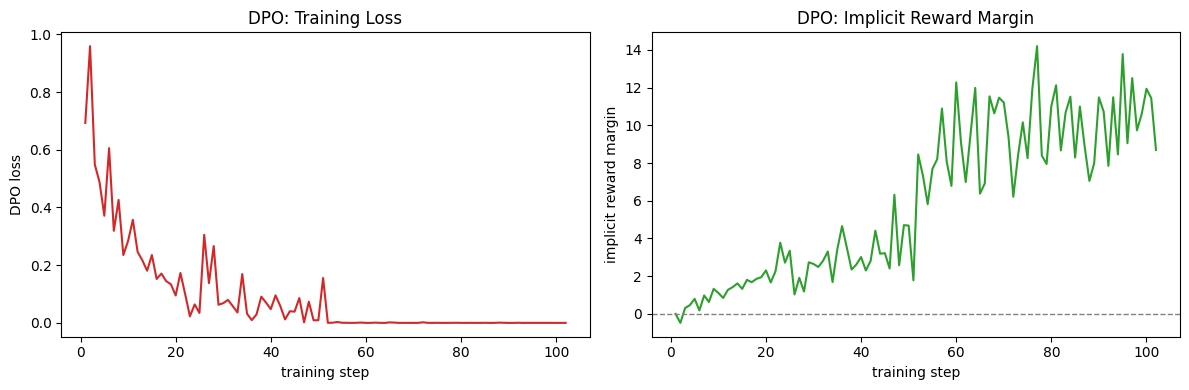

In [10]:
import matplotlib.pyplot as plt

steps = range(1, len(loss_history) + 1)
fig, (ax_loss, ax_margin) = plt.subplots(1, 2, figsize=(12, 4))

ax_loss.plot(steps, loss_history, color='tab:red')
ax_loss.set_xlabel('training step')
ax_loss.set_ylabel('DPO loss')
ax_loss.set_title('DPO: Training Loss')

ax_margin.plot(steps, margin_history, color='tab:green')
ax_margin.axhline(0.0, color='gray', linestyle='--', linewidth=1)
ax_margin.set_xlabel('training step')
ax_margin.set_ylabel('implicit reward margin')
ax_margin.set_title('DPO: Implicit Reward Margin')

plt.tight_layout()
plt.show()


> 📉 **Why does the loss fall close to zero?** On this small, clearly-separated set the model can satisfy almost every pair, so the DPO loss saturates near 0, that's *expected* here, not a bug. The meaningful checks are the **held-out win rate** and the **generated answers** below, both of which improve. On a large, noisy real dataset (e.g. `trl-lib/ultrafeedback_binarized`) the loss settles at a much higher value.


### For reference: the same DPO with TRL's `DPOTrainer`

In production you would usually use the maintained library rather than hand-writing the
loop. We implement DPO from scratch above so every step is transparent and so the notebook
runs on a clean Colab (TRL's `DPOTrainer` import currently pulls in optional model-merge /
judge dependencies). For production you'd also use a large **real** preference dataset (e.g. `trl-lib/ultrafeedback_binarized`) rather than a hand-curated one. The equivalent TRL code is:

```python
from trl import DPOConfig, DPOTrainer   # pip install trl  (+ optional extras)

args = DPOConfig(
    beta=0.1, learning_rate=1e-6,
    max_length=768, max_prompt_length=512,
    per_device_train_batch_size=1, gradient_accumulation_steps=4,
    num_train_epochs=1, output_dir="qwen-dpo",
)
trainer = DPOTrainer(
    model=model, args=args, processing_class=tokenizer,
    train_dataset=datasets["train"], eval_dataset=datasets["validation"],
)
trainer.train()   # DPOTrainer builds the frozen reference for you
```


In [11]:
get_win_rate(datasets['validation'])

100%|██████████| 13/13 [00:01<00:00, 11.78it/s]

Win rate: 100.00%


In [12]:
posttrain_outputs = []
print("=== After fine-tuning ===")
for i, (p, gt) in enumerate(zip(sample_prompts, sample_gt)):
    inputs = tokenizer(p, truncation=True, max_length=max_length,
                       return_attention_mask=True, return_tensors="pt").to(model.device)
    out_ids = model.generate(**inputs, max_new_tokens=200, do_sample=True,
                             temperature=0.7, pad_token_id=tokenizer.eos_token_id)[0]
    prediction = tokenizer.decode(out_ids[inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
    posttrain_outputs.append(prediction)
    print(f'--- #{i} | model answer (BEFORE DPO) ---')
    print(pretrain_outputs[i][:300])
    print(f'--- #{i} | model answer (AFTER DPO) ---')
    print(prediction[:300])
    print()


=== After fine-tuning ===
--- #0 | model answer (BEFORE DPO) ---
Staying calm during a job interview is crucial for several reasons:

1. **Professionalism**: A calm demeanor reflects professionalism and respect for the interviewer's time. It shows that you value their input and feel comfortable with them.

2. **Preparation**: Knowing what to expect from the inter
--- #0 | model answer (AFTER DPO) ---
Preparing beforehand and being fully prepared can help reduce nerves, and maintaining a positive mindset is key. A good atmosphere also makes you feel relaxed - think about the interviewer's questions first, and then focus on what you're going to say next. If possible, do some research before the in

--- #1 | model answer (BEFORE DPO) ---
Encryption refers to the process of converting data into an unreadable format so that only authorized parties can access it. This is often done using complex algorithms and keys that are used to transform the original information into something unintellig

### Conclusion

Using preference pairs alone, **no reward model and no RL loop**, DPO shifted the model toward **more concise, warmer, less-hedging** answers, and the win rate on held-out pairs rose sharply. This illustrates the common intuition: **DPO changes *how* the model responds** (style/tone), while SFT is better for changing *what* it says (facts/format). Which to choose depends on your task and data.

Chapter 8 extends this to **online DPO**, where the model generates its own candidate pairs during training.